In [20]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np


In [21]:

# ===== CAPA LEGENDRE =====
class PolynomialLegendre(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialLegendre, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim_leg = input_shape[-1]

        self.kernel_leg = self.add_weight(
            shape=(input_dim_leg * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel_leg"
        )

        if self.use_bias:
            self.bias_leg = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias_leg"
            )

    def call(self, inputs):
        x_leg = tf.cast(inputs, self.compute_dtype)
        
        p_nm2_leg = tf.ones_like(x_leg)
        p_nm1_leg = x_leg
        
        features_leg = [p_nm1_leg]

        for n in range(2, self.degree + 1):
            n_float_leg = tf.cast(n, self.compute_dtype)

            p_n_leg = ((2.0 * n_float_leg - 1.0) * x_leg * p_nm1_leg - (n_float_leg - 1.0) * p_nm2_leg) / n_float_leg
            features_leg.append(p_n_leg)
            
            p_nm2_leg = p_nm1_leg
            p_nm1_leg = p_n_leg

        phi_leg = tf.concat(features_leg, axis=-1)

        output_leg = tf.matmul(phi_leg, self.kernel_leg)

        if self.use_bias:
            output_leg = tf.nn.bias_add(output_leg, self.bias_leg)

        return output_leg


In [22]:
# ===== PLOT =====
def plot_cv_average_history_leg(histories_leg):
    max_epochs_leg = max([len(h.history['loss']) for h in histories_leg])
    epochs_leg = np.arange(1, max_epochs_leg + 1)

    def get_padded_metrics_leg(metric_name):
        matrix_leg = np.full((len(histories_leg), max_epochs_leg), np.nan)
        for i, h in enumerate(histories_leg):
            data_leg = h.history[metric_name]
            matrix_leg[i, :len(data_leg)] = data_leg
        return np.nanmean(matrix_leg, axis=0)

    avg_loss_leg = get_padded_metrics_leg('loss')
    avg_val_loss_leg = get_padded_metrics_leg('val_loss')
    avg_acc_leg = get_padded_metrics_leg('accuracy')
    avg_val_acc_leg = get_padded_metrics_leg('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_leg, avg_loss_leg)
    plt.plot(epochs_leg, avg_val_loss_leg)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_leg, avg_acc_leg)
    plt.plot(epochs_leg, avg_val_acc_leg)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [23]:
# ===== DATOS =====
magic_gamma_telescope_leg = fetch_ucirepo(id=159)

X_leg = magic_gamma_telescope_leg.data.features 
y_leg = magic_gamma_telescope_leg.data.targets 


In [24]:

epochs_leg = 120
batch_size_leg = 32
input_dim_leg = X_leg.shape[1]
num_splits_leg = 10


In [25]:
# ===== MODELO =====
def PolynomialDenseCreator_leg(degree_leg):
    inputPoli_leg = keras.Input(shape=(input_dim_leg,))
    
    x_leg = PolynomialLegendre(32, degree=degree_leg)(inputPoli_leg)
    x_leg = layers.Activation('swish')(x_leg)
    x_leg = layers.Dense(16, activation='swish')(x_leg)
    
    outputPoli_leg = layers.Dense(2, activation='softmax')(x_leg)
    
    model_leg = keras.Model(
        inputs=inputPoli_leg,
        outputs=outputPoli_leg,
        name=f"Polynomial_Model_Degree_{degree_leg}_leg"
    )
    
    model_leg.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_leg


In [26]:
def createEarlyStoppingCallback_leg(patience_leg=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_leg,
        restore_best_weights=True
    )

In [ ]:
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

skf_leg = StratifiedKFold(n_splits=num_splits_leg, shuffle=True, random_state=1)

fitHistory2_leg, fitHistory3_leg, fitHistory4_leg = [], [], []
scores2_leg, scores3_leg, scores4_leg = [], [], []

X_leg = X_leg.to_numpy()
y_leg = y_leg.to_numpy()


for train_index, test_index in tqdm(skf_leg.split(X_leg, y_leg), total=num_splits_leg):
    X_train_leg, X_test_leg = X_leg[train_index], X_leg[test_index]
    y_train_leg, y_test_leg = y_leg[train_index], y_leg[test_index]

    scaler_leg = MinMaxScaler(feature_range=(-1, 1))
    X_train_scaled_leg = scaler_leg.fit_transform(X_train_leg)
    X_test_scaled_leg = scaler_leg.transform(X_test_leg)

    y_train_leg = (y_train_leg == 'g').astype(int)
    y_test_leg = (y_test_leg == 'g').astype(int)

    model_poli2_leg = PolynomialDenseCreator_leg(degree_leg=2)
    model_poli3_leg = PolynomialDenseCreator_leg(degree_leg=3)
    model_poli4_leg = PolynomialDenseCreator_leg(degree_leg=4)

    history_poli2_leg = model_poli2_leg.fit(X_train_scaled_leg, y_train_leg, validation_split=0.2, epochs=epochs_leg,callbacks=[createEarlyStoppingCallback_leg()], batch_size=32, verbose=0)
    history_poli3_leg = model_poli3_leg.fit(X_train_scaled_leg, y_train_leg, validation_split=0.2, epochs=epochs_leg, callbacks=[createEarlyStoppingCallback_leg()], batch_size=32, verbose=0)
    history_poli4_leg = model_poli4_leg.fit(X_train_scaled_leg, y_train_leg, validation_split=0.2, epochs=epochs_leg, callbacks=[createEarlyStoppingCallback_leg()], batch _size=32, verbose=0)

    fitHistory2_leg.append(history_poli2_leg)
    fitHistory3_leg.append(history_poli3_leg)
    fitHistory4_leg.append(history_poli4_leg)

    scores2_leg.append(model_poli2_leg.evaluate(X_test_scaled_leg, y_test_leg, verbose=0))
    scores3_leg.append(model_poli3_leg.evaluate(X_test_scaled_leg, y_test_leg, verbose=0))
    scores4_leg.append(model_poli4_leg.evaluate(X_test_scaled_leg, y_test_leg, verbose=0))


100%|██████████| 10/10 [15:26<00:00, 92.62s/it]


In [28]:

def calculator_leg(scores_leg):
    Totalloss_leg, Totalaccuracy_leg = 0, 0
    for loss, accuracy in scores_leg:
        Totalloss_leg += loss
        Totalaccuracy_leg += accuracy

    return Totalloss_leg/num_splits_leg, Totalaccuracy_leg/num_splits_leg



  RESULTADOS FINALES (Promedio CV - Legendre)
Grado 2 - Loss: 0.3450, Acc: 0.8576
Grado 3 - Loss: 0.3245, Acc: 0.8668
Grado 4 - Loss: 0.3334, Acc: 0.8641


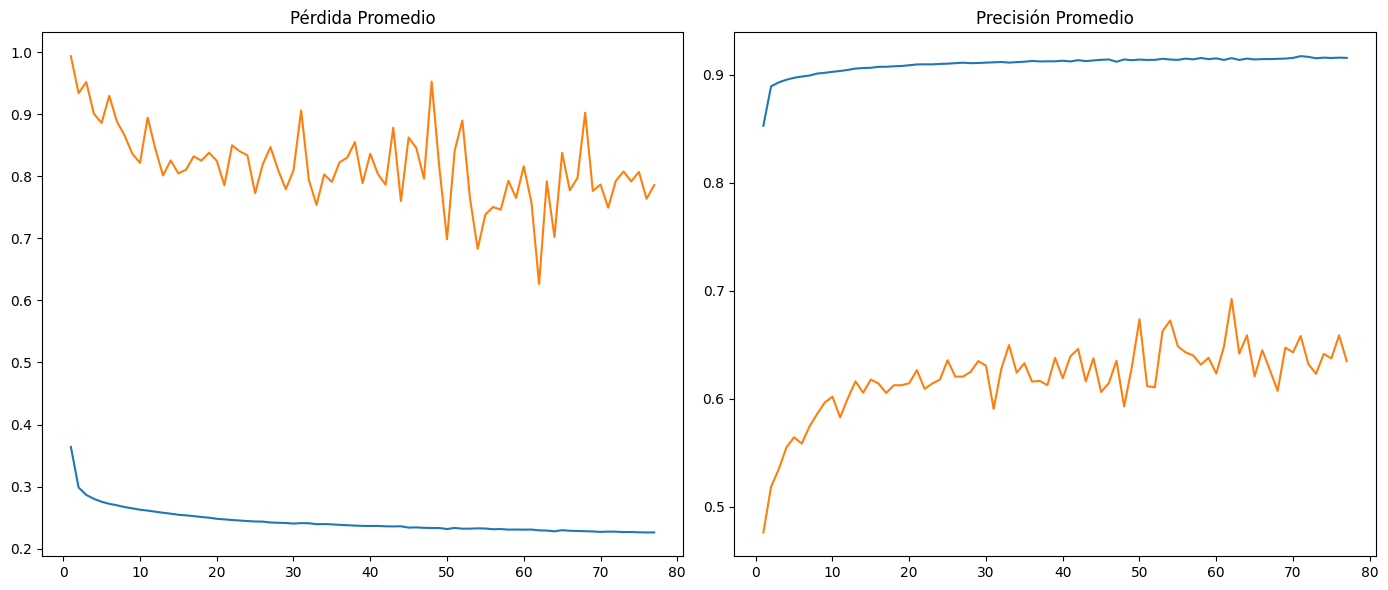

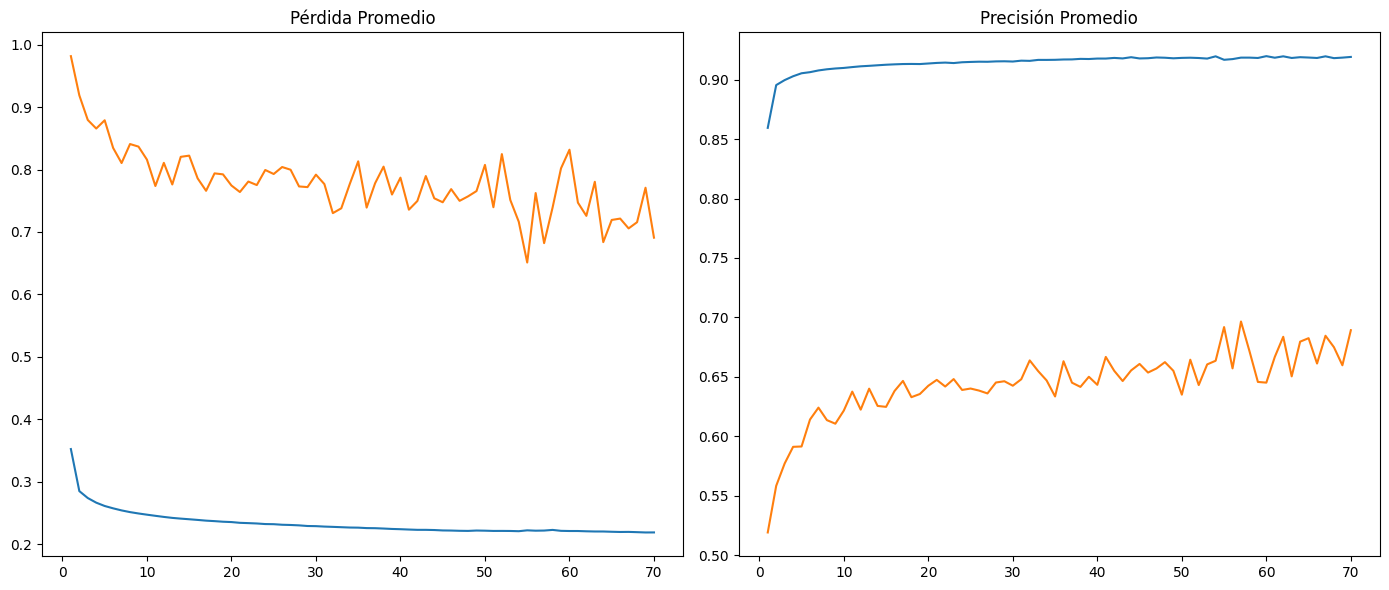

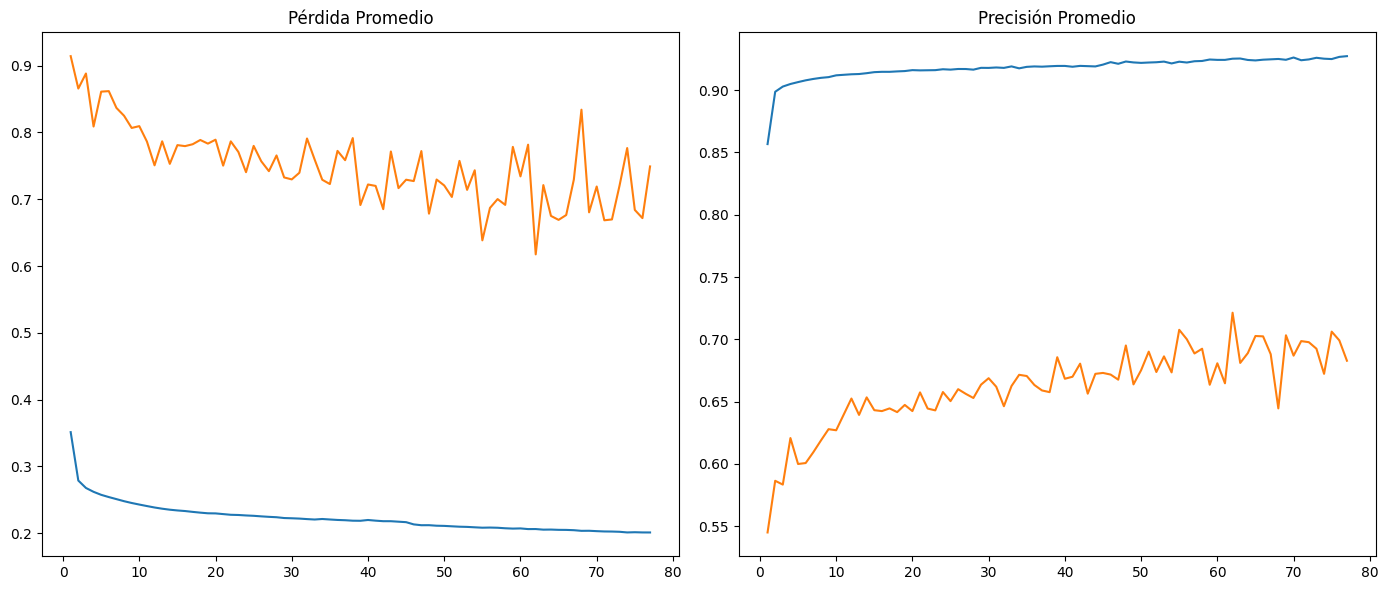

In [29]:

results2_leg = calculator_leg(scores2_leg)
results3_leg = calculator_leg(scores3_leg)
results4_leg = calculator_leg(scores4_leg)


print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Legendre)")
print("="*40)
print(f"Grado 2 - Loss: {results2_leg[0]:.4f}, Acc: {results2_leg[1]:.4f}")
print(f"Grado 3 - Loss: {results3_leg[0]:.4f}, Acc: {results3_leg[1]:.4f}")
print(f"Grado 4 - Loss: {results4_leg[0]:.4f}, Acc: {results4_leg[1]:.4f}")


plot_cv_average_history_leg(fitHistory2_leg)
plot_cv_average_history_leg(fitHistory3_leg)
plot_cv_average_history_leg(fitHistory4_leg)